In [131]:
import torch
import os
import re
import pdfplumber
import pandas as pd
#from sklearn.regression impor r

In [2]:
torch.cuda.is_available()

True

In [20]:
from pathlib import Path

VACANCY_FOLDER = Path("vacancy_train")
RESUMES_FOLDER = Path("resume_train")

assert VACANCY_FOLDER.exists(), f" Не найден папка {VACANCY_FOLDER}"
assert RESUMES_FOLDER.exists(), f" Не найдена папка {RESUMES_FOLDER}"

pdf_files = sorted(RESUMES_FOLDER.glob("*.pdf"))
assert pdf_files, f" В папке {RESUMES_FOLDER} нет PDF"
pdf_files_vacansy=sorted(VACANCY_FOLDER.glob("*.pdf"))

print(f" Вакансия: {VACANCY_FOLDER}")
for p in pdf_files_vacansy:
    print(f"   - {p.name}")
print(f" Резюме ({len(pdf_files)}):")
for p in pdf_files:
    print(f"   - {p.name}")

 Вакансия: vacancy_train
   - Вакансия 1.pdf
   - Вакансия 2.pdf
   - Вакансия 3.pdf
   - Вакансия 4.pdf
   - Вакансия 5.pdf
 Резюме (30):
   - Резюме 1-1.pdf
   - Резюме 1-2.pdf
   - Резюме 1-3.pdf
   - Резюме 1-4.pdf
   - Резюме 1-5.pdf
   - Резюме 2-1.pdf
   - Резюме 2-2.pdf
   - Резюме 2-3.pdf
   - Резюме 2-4.pdf
   - Резюме 2-5.pdf
   - Резюме 3-1.pdf
   - Резюме 3-2.pdf
   - Резюме 3-3.pdf
   - Резюме 3-4.pdf
   - Резюме 3-5.pdf
   - Резюме 4-1.pdf
   - Резюме 4-2.pdf
   - Резюме 4-3.pdf
   - Резюме 4-4.pdf
   - Резюме 4-5.pdf
   - Резюме 5-1.pdf
   - Резюме 5-2.pdf
   - Резюме 5-3.pdf
   - Резюме 5-4.pdf
   - Резюме 5-5.pdf
   - Резюме 6-1.pdf
   - Резюме 6-2.pdf
   - Резюме 6-3.pdf
   - Резюме 6-4.pdf
   - Резюме 6-5.pdf


# Собираем данные для обучения

In [21]:
import re
import pdfplumber

def read_pdf(path: Path) -> str:
    """Извлекает текст из PDF, чистит лишние пробелы."""
    pages = []
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            pages.append(page.extract_text() or "")
    text = "\n".join(pages)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


# Читаем вакансию


vacancy_data=[]
for path in pdf_files_vacansy:
    vacancy_text = read_pdf(path)
    if len(vacancy_text) < 50:
        print(f"    {path.name}: слишком мало текста, пропускаю")
        continue
    vacancy_data.append(({"file": path.name, "text": vacancy_text}))
    print(f" {path.name}: {len(vacancy_text)} символов")
print(f"\n Готово: {len(vacancy_data)} вакансии")

# Читаем резюме
resumes_data = []
for path in pdf_files:
    text = read_pdf(path)
    if len(text) < 50:
        print(f"    {path.name}: слишком мало текста, пропускаю")
        continue
    resumes_data.append({"file": path.name, "text": text})
    print(f" {path.name}: {len(text)} символов")

print(f"\n Готово: {len(resumes_data)} резюме")

 Вакансия 1.pdf: 2201 символов
 Вакансия 2.pdf: 1507 символов
 Вакансия 3.pdf: 1523 символов
 Вакансия 4.pdf: 1327 символов
 Вакансия 5.pdf: 1293 символов

 Готово: 5 вакансии
 Резюме 1-1.pdf: 2506 символов
 Резюме 1-2.pdf: 1440 символов
 Резюме 1-3.pdf: 3405 символов
 Резюме 1-4.pdf: 1547 символов
 Резюме 1-5.pdf: 3210 символов
 Резюме 2-1.pdf: 1909 символов
 Резюме 2-2.pdf: 3092 символов
 Резюме 2-3.pdf: 2779 символов
 Резюме 2-4.pdf: 4797 символов
 Резюме 2-5.pdf: 3314 символов
 Резюме 3-1.pdf: 1619 символов
 Резюме 3-2.pdf: 4391 символов
 Резюме 3-3.pdf: 1143 символов
 Резюме 3-4.pdf: 1020 символов
 Резюме 3-5.pdf: 3152 символов
 Резюме 4-1.pdf: 2611 символов
 Резюме 4-2.pdf: 3253 символов
 Резюме 4-3.pdf: 489 символов
 Резюме 4-4.pdf: 611 символов
 Резюме 4-5.pdf: 4402 символов
 Резюме 5-1.pdf: 3202 символов
 Резюме 5-2.pdf: 1291 символов
 Резюме 5-3.pdf: 2488 символов
 Резюме 5-4.pdf: 1121 символов
 Резюме 5-5.pdf: 905 символов
 Резюме 6-1.pdf: 3058 символов
 Резюме 6-2.pdf: 2805

In [22]:
import numpy as np
from sentence_transformers import SentenceTransformer
import gc

list_cos_for_regression=[]


EMBEDDING_MODEL = "intfloat/multilingual-e5-large"

#print(f"🔢 Загружаю {EMBEDDING_MODEL} на CPU...")
#print("   (на CPU будет немного медленнее, но не съест VRAM для vLLM)")
embedder = SentenceTransformer(EMBEDDING_MODEL, device="cuda")

all_texts = [f"passage: {v['text']}" for v in vacancy_data] + [f"passage: {r['text']}" for r in resumes_data]
embeddings = embedder.encode(
    all_texts,
    normalize_embeddings=True,
    show_progress_bar=True,
)

# Сразу выгружаем эмбеддер из памяти
del embedder
gc.collect()
list_for_llm=[]
variable_count_judge=len(pdf_files) #Переменая определяет скольких кандидатов мы отправим на оценку в LLM
#vacancy_emb = embeddings[0]

for vacancy,emb_v in (zip(vacancy_data,embeddings[0:len(vacancy_data)])):
    print(f"\n Cosine similarity с вакансией: {vacancy['file']}")
    cosine_scores=[]
    for resume, emb_r in zip(resumes_data, embeddings[len(vacancy_data):]):
        cos = float(np.dot(emb_v, emb_r))
        resume["cosine_score"] = cos
        #dict_cos[resume]=cos
        cosine_scores.append((resume, cos))
        
    cosine_scores.sort(key=lambda x: x[1], reverse=True)
    for key in cosine_scores:
        print(f"   {key[0]['file']:30s}  cos = {key[1]:.4f}")
        list_cos_for_regression.append(round(key[1],4))
    #Отберем топ кандидатов к вакансии создадим кортеж и их будем прогонять через LLM для выставления скорее которое создадим по переменой variable_count_judge
    
    list_for_llm.append({
    "vacancy": vacancy,
    "top_candidates": [resume for resume, _ in cosine_scores[:variable_count_judge]]})
        

Batches: 100%|██████████| 2/2 [00:01<00:00,  1.53it/s]



 Cosine similarity с вакансией: Вакансия 1.pdf
   Резюме 6-1.pdf                  cos = 0.8973
   Резюме 5-1.pdf                  cos = 0.8865
   Резюме 2-1.pdf                  cos = 0.8674
   Резюме 4-5.pdf                  cos = 0.8672
   Резюме 3-5.pdf                  cos = 0.8661
   Резюме 2-4.pdf                  cos = 0.8657
   Резюме 3-1.pdf                  cos = 0.8654
   Резюме 5-5.pdf                  cos = 0.8645
   Резюме 6-2.pdf                  cos = 0.8617
   Резюме 3-2.pdf                  cos = 0.8615
   Резюме 1-5.pdf                  cos = 0.8611
   Резюме 4-1.pdf                  cos = 0.8605
   Резюме 6-5.pdf                  cos = 0.8595
   Резюме 2-5.pdf                  cos = 0.8590
   Резюме 1-1.pdf                  cos = 0.8586
   Резюме 5-2.pdf                  cos = 0.8551
   Резюме 5-3.pdf                  cos = 0.8531
   Резюме 1-4.pdf                  cos = 0.8517
   Резюме 6-3.pdf                  cos = 0.8501
   Резюме 2-3.pdf                  cos =

In [23]:
#prefiltered = []
#for i in range(6):  # вакансии
#    for j in range(120):  # кандидаты
 #       if cosine_sim[i,j] > 0.4 or (llm_scores[i,j]/100) > 0.4:
 #           prefiltered.append((i, j, cosine_sim[i,j], llm_scores[i,j]))

#print(f"Отфильтровано: {len(prefiltered)} пар из 720")

In [ ]:
import subprocess

# Убиваем старый контейнер
subprocess.run("docker stop vllm 2>nul & docker rm vllm 2>nul", shell=True)

# Запускаем vLLM в Docker
cmd = f"""docker run --gpus all -d -p 8000:8000 --name vllm2 vllm/vllm-openai:latest --model Qwen/Qwen2.5-7B-Instruct-AWQ --quantization awq --dtype half --max-model-len 4096 --gpu-memory-utilization 0.80"""

subprocess.run(cmd, shell=True)
print("🐳 Docker-контейнер vLLM запущен")

In [24]:
VLLM_MODEL = "Qwen/Qwen2.5-7B-Instruct-AWQ"
import json
import re
from openai import OpenAI

# Клиент к локальному vLLM (OpenAI-совместимый API)
client = OpenAI(base_url="http://localhost:8000/v1", api_key="EMPTY")


JUDGE_SYSTEM_PROMPT = """ Оцени соответствие кандидата вакансии по шкале от 0 до 100.
    Отвечай только на русском языке. Технологии могут быть на английском.
 Ответь строго одним JSON-объектом без пояснений до и после: {{"score": число, "reasoning": "краткое обоснование"}}

"""


def parse_judge_response(raw: str) -> dict:
    """Парсит JSON из ответа LLM, чистит markdown-обёртки."""
    raw = raw.strip()
    raw = re.sub(r"^```(?:json)?\s*", "", raw)
    raw = re.sub(r"\s*```$", "", raw)
    match = re.search(r"\{.*\}", raw, re.DOTALL)
    if match:
        raw = match.group(0)
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {"score": 0, "reasoning": "Ошибка парсинга"}


def evaluate_resume(vacancy: str, resume: str) -> dict:
    """Получает оценку резюме через LLM."""
    user_prompt = (
        f"ВАКАНСИЯ:\n{vacancy[:6000]}\n\n"
        f"═══════════════════════════════════════\n\n"
        f"РЕЗЮМЕ КАНДИДАТА:\n{resume[:6000]}\n\n"
        f"═══════════════════════════════════════\n\n"
        f"Оцени соответствие. Верни только JSON."
    )

    response = client.chat.completions.create(
        model=VLLM_MODEL,
        messages=[
            {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt},
        ],
        temperature=0.1,
        max_tokens=600,
    )
    return parse_judge_response(response.choices[0].message.content)


In [25]:
list_score_for_regression=[]

In [26]:

for llm_score in list_for_llm:
    vacancy=llm_score['vacancy']
    resumes_data=llm_score['top_candidates']
    # Прогоняем все резюме через LLM
    print(f"\n Оцениваю {len(resumes_data)} резюме через {VLLM_MODEL} на вакансию {vacancy['file']}\n")
    for i, resume in enumerate(resumes_data, 1):
        print(f"   [{i}/{len(resumes_data)}] {resume['file']}...", end=" ", flush=True)
        try:
            result = evaluate_resume(vacancy['text'], resume["text"])
            resume["llm_score"] = float(result.get("score", 0))
            resume["llm_summary"] = result.get("reasoning", "")
            #resume["llm_pros"] = result.get("pros", [])
            #resume["llm_cons"] = result.get("cons", [])
            
            print(f"оценка: {resume['llm_score']:.0f}/100")
           
            print(resume["llm_summary"])
            list_score_for_regression.append(resume['llm_score'])
        except Exception as exc:
            print(f"ошибка: {exc}")
            resume["llm_score"] = 0
            resume["llm_summary"] = f"Ошибка: {exc}"
            #resume["llm_pros"] = []
            #resume["llm_cons"] = []


 Оцениваю 30 резюме через Qwen/Qwen2.5-7B-Instruct-AWQ на вакансию Вакансия 1.pdf

   [1/30] Резюме 6-1.pdf... оценка: 85/100
Кандидат имеет достаточный опыт в наладке и испытаниях электрооборудования, а также в релейной защите и автоматике. Он готов к переездам и командировкам, что соответствует требованиям вакансии. Однако его опыт не полностью совпадает с конкретными требованиями вакансии, так как он не указывает опыт в наладке и испытаниях РУ-10кВ.
   [2/30] Резюме 5-1.pdf... оценка: 85/100
Кандидат имеет достаточный опыт работы в области наладки и испытаний электрооборудования, а также соответствует требованиям по образованию. Он готов к командировкам и переезду, что соответствует условиям вакансии. Однако он не указывает конкретного опыта в настройке и наладке защит РУ-10кВ, что является обязательным требованием.
   [3/30] Резюме 2-1.pdf... оценка: 85/100
Кандидат имеет значительный опыт работы в области электромонтажа и испытаний, что соответствует требованиям вакансии. Он имее

In [6]:
print(list_score_for_regression)
print(len(list_score_for_regression))

NameError: name 'list_score_for_regression' is not defined

In [ ]:
print(list_cos_for_regression)

[0.8973, 0.8865, 0.8674, 0.8672, 0.8661, 0.8657, 0.8654, 0.8645, 0.8617, 0.8615, 0.8611, 0.8605, 0.8595, 0.859, 0.8586, 0.8551, 0.8531, 0.8517, 0.8501, 0.85, 0.8457, 0.8455, 0.8443, 0.8401, 0.8388, 0.8364, 0.8364, 0.8284, 0.8204, 0.8197, 0.8988, 0.8952, 0.8831, 0.8756, 0.8738, 0.8733, 0.8721, 0.8633, 0.8619, 0.8601, 0.8561, 0.8554, 0.8499, 0.8486, 0.8443, 0.8356, 0.8351, 0.8328, 0.8325, 0.8313, 0.8297, 0.8275, 0.8272, 0.8265, 0.8229, 0.8226, 0.82, 0.8162, 0.8122, 0.8087, 0.9024, 0.8955, 0.8857, 0.875, 0.871, 0.8678, 0.8641, 0.8592, 0.8555, 0.8541, 0.8472, 0.8335, 0.833, 0.8326, 0.8326, 0.832, 0.8311, 0.8276, 0.8247, 0.8212, 0.8179, 0.8117, 0.8109, 0.8108, 0.809, 0.8088, 0.8081, 0.805, 0.8009, 0.7967, 0.8932, 0.8916, 0.8808, 0.8701, 0.8638, 0.8588, 0.8582, 0.8461, 0.8414, 0.836, 0.8352, 0.8282, 0.8253, 0.8246, 0.8225, 0.8211, 0.82, 0.8184, 0.8151, 0.8137, 0.8134, 0.8127, 0.8123, 0.8092, 0.8081, 0.8081, 0.8076, 0.8047, 0.8002, 0.799, 0.8618, 0.8549, 0.8546, 0.8535, 0.8515, 0.8507, 0.849,

# Сборка данных к обучению модели финальной оценки(калибровка cos и LLM score относительно ручной разметки)

In [5]:
import pandas as pd

Размеченные данные для обучающей выборки вручную:

```
Cosine similarity с вакансией: Вакансия 1.pdf		
   Резюме 6-1.pdf                  cos = 0.8973		100,
   Резюме 5-1.pdf                  cos = 0.8865		100,
   Резюме 2-1.pdf                  cos = 0.8674		70,
   Резюме 4-5.pdf                  cos = 0.8672		40,
   Резюме 3-5.pdf                  cos = 0.8661		45,
   Резюме 2-4.pdf                  cos = 0.8657		35,
   Резюме 3-1.pdf                  cos = 0.8654		88,
   Резюме 5-5.pdf                  cos = 0.8645		45,
   Резюме 6-2.pdf                  cos = 0.8617		45,
   Резюме 3-2.pdf                  cos = 0.8615		40,
   Резюме 1-5.pdf                  cos = 0.8611		65,
   Резюме 4-1.pdf                  cos = 0.8605		70,
   Резюме 6-5.pdf                  cos = 0.8595		50,
   Резюме 2-5.pdf                  cos = 0.8590		54,
   Резюме 1-1.pdf                  cos = 0.8586		53,
   Резюме 5-2.pdf                  cos = 0.8551		67,
   Резюме 5-3.pdf                  cos = 0.8531		70,
   Резюме 1-4.pdf                  cos = 0.8517		60,
   Резюме 6-3.pdf                  cos = 0.8501		45,
   Резюме 2-3.pdf                  cos = 0.8500		55,
   Резюме 3-3.pdf                  cos = 0.8457		40,
   Резюме 4-2.pdf                  cos = 0.8455		35,
   Резюме 6-4.pdf                  cos = 0.8443		35,
   Резюме 1-3.pdf                  cos = 0.8401		70,
   Резюме 1-2.pdf                  cos = 0.8388		73,
   Резюме 2-2.pdf                  cos = 0.8364		67,
   Резюме 5-4.pdf                  cos = 0.8364		39,
   Резюме 4-3.pdf                  cos = 0.8284		35,
   Резюме 3-4.pdf                  cos = 0.8204		33,
   Резюме 4-4.pdf                  cos = 0.8197		28,
        
 Cosine similarity с вакансией: Вакансия 2.pdf		
   Резюме 3-2.pdf                  cos = 0.8988		100,
   Резюме 5-2.pdf                  cos = 0.8952		93,
   Резюме 1-2.pdf                  cos = 0.8831		80,
   Резюме 2-2.pdf                  cos = 0.8756		100,
   Резюме 6-2.pdf                  cos = 0.8738		90,
   Резюме 2-4.pdf                  cos = 0.8733		93,
   Резюме 4-2.pdf                  cos = 0.8721		85,
   Резюме 2-1.pdf                  cos = 0.8633		80,
   Резюме 3-5.pdf                  cos = 0.8619		79,
   Резюме 6-5.pdf                  cos = 0.8601		30,
   Резюме 1-5.pdf                  cos = 0.8561		70,
   Резюме 4-5.pdf                  cos = 0.8554		65,
   Резюме 5-1.pdf                  cos = 0.8499		60,
   Резюме 6-4.pdf                  cos = 0.8486		50,
   Резюме 1-4.pdf                  cos = 0.8443		67,
   Резюме 5-5.pdf                  cos = 0.8356		45,
   Резюме 6-1.pdf                  cos = 0.8351		62,
   Резюме 1-3.pdf                  cos = 0.8328		35,
   Резюме 1-1.pdf                  cos = 0.8325		32,
   Резюме 5-4.pdf                  cos = 0.8313		45,
   Резюме 2-5.pdf                  cos = 0.8297		54,
   Резюме 2-3.pdf                  cos = 0.8275		43,
   Резюме 4-1.pdf                  cos = 0.8272		30,
   Резюме 3-1.pdf                  cos = 0.8265		29,
   Резюме 4-4.pdf                  cos = 0.8229		25,
   Резюме 3-3.pdf                  cos = 0.8226		40,
   Резюме 6-3.pdf                  cos = 0.8200		35,
   Резюме 3-4.pdf                  cos = 0.8162		42,
   Резюме 5-3.pdf                  cos = 0.8122		33,
   Резюме 4-3.pdf                  cos = 0.8087		28,
        
 Cosine similarity с вакансией: Вакансия 3.pdf		
   Резюме 2-3.pdf                  cos = 0.9024		90,
   Резюме 4-3.pdf                  cos = 0.8955		93,
   Резюме 1-3.pdf                  cos = 0.8857		100,
   Резюме 3-3.pdf                  cos = 0.8750		90,
   Резюме 3-5.pdf                  cos = 0.8710		75,
   Резюме 1-5.pdf                  cos = 0.8678		58,
   Резюме 2-5.pdf                  cos = 0.8641		53,
   Резюме 5-3.pdf                  cos = 0.8592		85,
   Резюме 1-4.pdf                  cos = 0.8555		48,
   Резюме 3-1.pdf                  cos = 0.8541		40,
   Резюме 2-4.pdf                  cos = 0.8472		38,
   Резюме 6-1.pdf                  cos = 0.8335		40,
   Резюме 5-2.pdf                  cos = 0.8330		42,
   Резюме 2-1.pdf                  cos = 0.8326		38,
   Резюме 6-3.pdf                  cos = 0.8326		73,
   Резюме 4-4.pdf                  cos = 0.8320		29,
   Резюме 5-4.pdf                  cos = 0.8311		26,
   Резюме 5-1.pdf                  cos = 0.8276		25,
   Резюме 2-2.pdf                  cos = 0.8247		35,
   Резюме 5-5.pdf                  cos = 0.8212		10,
   Резюме 6-5.pdf                  cos = 0.8179		9,
   Резюме 3-2.pdf                  cos = 0.8117		15,
   Резюме 1-2.pdf                  cos = 0.8109		13,
   Резюме 4-1.pdf                  cos = 0.8108		4,
   Резюме 6-4.pdf                  cos = 0.8090		20,
   Резюме 4-5.pdf                  cos = 0.8088		5,
   Резюме 6-2.pdf                  cos = 0.8081		7,
   Резюме 4-2.pdf                  cos = 0.8050		13,
   Резюме 1-1.pdf                  cos = 0.8009		10,
   Резюме 3-4.pdf                  cos = 0.7967		20,
        
 Cosine similarity с вакансией: Вакансия 4.pdf		
   Резюме 3-4.pdf                  cos = 0.8932		100,
   Резюме 6-4.pdf                  cos = 0.8916		100,
   Резюме 1-4.pdf                  cos = 0.8808		89,
   Резюме 5-4.pdf                  cos = 0.8701		85,
   Резюме 2-4.pdf                  cos = 0.8638		87,
   Резюме 5-2.pdf                  cos = 0.8588		88,
   Резюме 4-4.pdf                  cos = 0.8582		80,
   Резюме 2-5.pdf                  cos = 0.8461		85,
   Резюме 2-1.pdf                  cos = 0.8414		80,
   Резюме 6-5.pdf                  cos = 0.8360		70,
   Резюме 3-2.pdf                  cos = 0.8352		78,
   Резюме 3-5.pdf                  cos = 0.8282		85,
   Резюме 5-1.pdf                  cos = 0.8253		68,
   Резюме 1-5.pdf                  cos = 0.8246		85,
   Резюме 6-1.pdf                  cos = 0.8225		60,
   Резюме 1-2.pdf                  cos = 0.8211		65,
   Резюме 4-5.pdf                  cos = 0.8200		63,
   Резюме 1-3.pdf                  cos = 0.8184		40,
   Резюме 5-3.pdf                  cos = 0.8151		20,
   Резюме 2-3.pdf                  cos = 0.8137		15,
   Резюме 5-5.pdf                  cos = 0.8134		23,
   Резюме 2-2.pdf                  cos = 0.8127		27,
   Резюме 6-2.pdf                  cos = 0.8123		22,
   Резюме 3-1.pdf                  cos = 0.8092		20,
   Резюме 4-2.pdf                  cos = 0.8081		15,
   Резюме 4-3.pdf                  cos = 0.8081		5,
   Резюме 3-3.pdf                  cos = 0.8076		4,
   Резюме 6-3.pdf                  cos = 0.8047		3,
   Резюме 1-1.pdf                  cos = 0.8002		3,
   Резюме 4-1.pdf                  cos = 0.7990		2,
        
 Cosine similarity с вакансией: Вакансия 5.pdf		
   Резюме 5-5.pdf                  cos = 0.8618		80,
   Резюме 3-5.pdf                  cos = 0.8549		83,
   Резюме 3-1.pdf                  cos = 0.8546		80,
   Резюме 2-4.pdf                  cos = 0.8535		93,
   Резюме 4-5.pdf                  cos = 0.8515		95,
   Резюме 3-2.pdf                  cos = 0.8507		94,
   Резюме 1-1.pdf                  cos = 0.8490		70,
   Резюме 2-1.pdf                  cos = 0.8462		45,
   Резюме 6-1.pdf                  cos = 0.8448		30,
   Резюме 1-5.pdf                  cos = 0.8433		27,
   Резюме 5-1.pdf                  cos = 0.8428		35,
   Резюме 2-5.pdf                  cos = 0.8426		65,
   Резюме 5-2.pdf                  cos = 0.8424		35,
   Резюме 6-5.pdf                  cos = 0.8413		60,
   Резюме 3-3.pdf                  cos = 0.8319		10,
   Резюме 6-4.pdf                  cos = 0.8316		20,
   Резюме 1-2.pdf                  cos = 0.8304		35,
   Резюме 2-2.pdf                  cos = 0.8295		70,
   Резюме 1-4.pdf                  cos = 0.8272		40,
   Резюме 5-4.pdf                  cos = 0.8266		20,
   Резюме 1-3.pdf                  cos = 0.8264		15,
   Резюме 4-1.pdf                  cos = 0.8247		14,
   Резюме 5-3.pdf                  cos = 0.8244		10,
   Резюме 2-3.pdf                  cos = 0.8230		0,
   Резюме 6-2.pdf                  cos = 0.8221		2,
   Резюме 6-3.pdf                  cos = 0.8198		0,
   Резюме 3-4.pdf                  cos = 0.8183		0,
   Резюме 4-2.pdf                  cos = 0.8180		4,
   Резюме 4-3.pdf                  cos = 0.8147		2,
   Резюме 4-4.pdf                  cos = 0.8041		1
```

In [817]:
list_score_llm=[85.0, 85.0, 85.0, 65.0, 85.0, 75.0, 65.0, 65.0, 65.0, 75.0, 85.0, 30.0, 65.0, 65.0, 65.0, 75.0, 65.0, 65.0, 65.0, 65.0, 55.0, 20.0, 65.0, 75.0, 65.0, 65.0, 25.0, 
                30.0, 65.0, 20.0, 95.0, 95.0, 85.0, 85.0, 92.0, 85.0, 95.0, 85.0, 95.0, 75.0, 95.0, 85.0, 85.0, 75.0, 75.0, 65.0, 85.0, 75.0, 85.0, 35.0, 65.0, 65.0, 65.0, 75.0, 
                20.0, 65.0, 75.0, 65.0, 65.0, 55.0, 90.0, 75.0, 95.0, 65.0, 85.0, 85.0, 75.0, 65.0, 75.0, 65.0, 85.0, 85.0, 75.0, 85.0, 65.0, 45.0, 75.0, 85.0, 75.0, 65.0, 75.0, 
                75.0, 65.0, 65.0, 85.0, 65.0, 65.0, 20.0, 65.0, 65.0, 85.0, 85.0, 85.0, 75.0, 85.0, 85.0, 65.0, 85.0, 95.0, 75.0, 85.0, 85.0, 85.0, 85.0, 85.0, 65.0, 65.0, 85.0, 
                75.0, 75.0, 65.0, 85.0, 75.0, 65.0, 35.0, 75.0, 75.0, 75.0, 75.0, 65.0, 75.0, 85.0, 65.0, 85.0, 85.0, 92.0, 75.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 65.0, 
                85.0, 65.0, 85.0, 75.0, 55.0, 85.0, 65.0, 75.0, 75.0, 85.0, 75.0, 75.0, 65.0, 75.0, 45.0]
list_score_cos=[0.8973, 0.8865, 0.8674, 0.8672, 0.8661, 0.8657, 0.8654, 0.8645, 0.8617, 0.8615, 0.8611, 0.8605, 0.8595, 0.859, 0.8586, 0.8551, 0.8531, 0.8517, 0.8501, 0.85, 0.8457,
                 0.8455, 0.8443, 0.8401, 0.8388, 0.8364, 0.8364, 0.8284, 0.8204, 0.8197, 0.8988, 0.8952, 0.8831, 0.8756, 0.8738, 0.8733, 0.8721, 0.8633, 0.8619, 0.8601, 0.8561, 
                 0.8554, 0.8499, 0.8486, 0.8443, 0.8356, 0.8351, 0.8328, 0.8325, 0.8313, 0.8297, 0.8275, 0.8272, 0.8265, 0.8229, 0.8226, 0.82, 0.8162, 0.8122, 0.8087, 0.9024,
                   0.8955, 0.8857, 0.875, 0.871, 0.8678, 0.8641, 0.8592, 0.8555, 0.8541, 0.8472, 0.8335, 0.833, 0.8326, 0.8326, 0.832, 0.8311, 0.8276, 0.8247, 0.8212, 0.8179, 
                   0.8117, 0.8109, 0.8108, 0.809, 0.8088, 0.8081, 0.805, 0.8009, 0.7967, 0.8932, 0.8916, 0.8808, 0.8701, 0.8638, 0.8588, 0.8582, 0.8461, 0.8414, 0.836, 0.8352, 
                   0.8282, 0.8253, 0.8246, 0.8225, 0.8211, 0.82, 0.8184, 0.8151, 0.8137, 0.8134, 0.8127, 0.8123, 0.8092, 0.8081, 0.8081, 0.8076, 0.8047, 0.8002, 0.799, 0.8618, 
                   0.8549, 0.8546, 0.8535, 0.8515, 0.8507, 0.849, 0.8462, 0.8448, 0.8433, 0.8428, 0.8426, 0.8424, 0.8413, 0.8319, 0.8316, 0.8304, 0.8295, 0.8272, 0.8266, 0.8264,
                     0.8247, 0.8244, 0.823, 0.8221, 0.8198, 0.8183, 0.818, 0.8147, 0.8041]
list_score_manual = [100,100,70,40,45,35,88,45,45,40,65,70,50,54,53,67,70,60,45,55,40,35,35,70,73,67,39,35,33,28,100,93,80,100,90,93,85,80,79,30,70,65,60,50,67,45,62,35,32,45,54,
                     43,30,29,25,40,35,42,33,28,90,93,100,90,75,58,53,85,48,40,38,40,42,38,73,29,26,25,35,10,9,15,13,4,20,5,7,13,10,20,100,100,89,85,87,88,80,85,80,70,78,85,68,85,
                     60,65,63,40,20,15,23,27,22,20,15,5,4,3,3,2,80,83,80,93,95,94,70,45,30,27,35,65,35,60,10,20,35,70,40,20,15,14,10,0,2,0,0,4,2,1]

In [818]:
print(len(list_score_llm))
print(len(list_score_cos))
print(len(list_score_manual))

150
150
150


In [771]:
df_train=pd.DataFrame(columns=['list_score_llm','list_score_cos','list_score_manual'])
df_train["list_score_llm"]=list_score_llm
df_train["list_score_cos"]=list_score_cos
df_train['list_score_manual']=list_score_manual
df_train['llm_cos_interaction'] = df_train['list_score_llm'] * df_train['list_score_cos']
#df_train['llm_squared'] = df_train['list_score_llm'] ** 2
#df_train['cos_squared'] = df_train['list_score_cos'] ** 2
#df_train.drop(columns='list_score_cos',inplace=True)

In [772]:
df_train.describe()

,list_score_llm,list_score_cos,list_score_manual,llm_cos_interaction
count,150.000000,150.000000,150.000000,150.000000
mean,72.726667,0.840847,48.520000,61.289187
std,15.710851,0.024402,29.589296,13.915949
min,20.000000,0.796700,0.000000,16.100000
25%,65.000000,0.822200,26.250000,54.167750
50%,75.000000,0.836400,45.000000,62.013750
75%,85.000000,0.858950,72.250000,71.616750
max,95.000000,0.902400,100.000000,85.386000


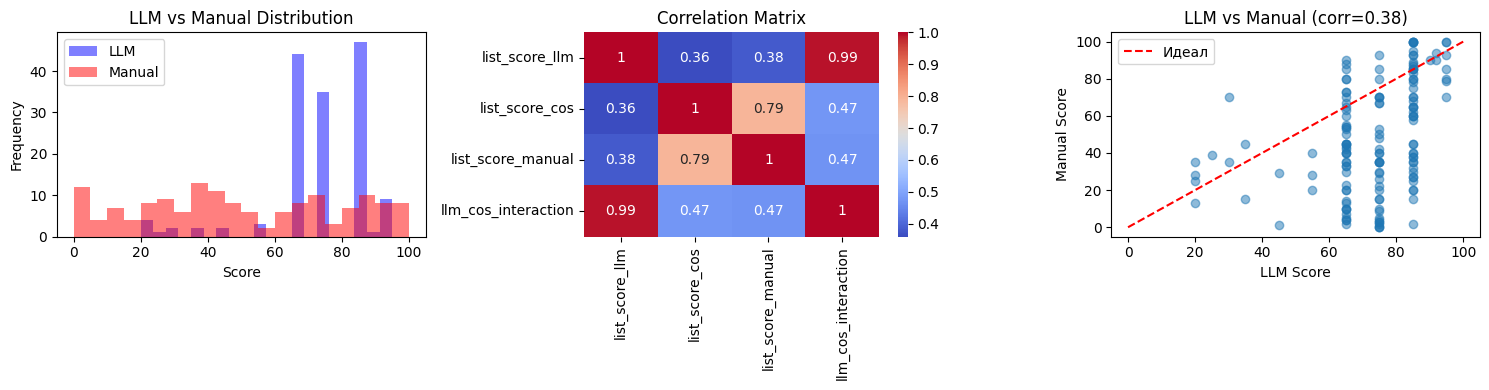


=== Диагностика ===
Корреляция LLM vs Manual: 0.382
Корреляция COS vs Manual: 0.790

R² только с LLM: 0.146
R² с LLM + COS: 0.635
Улучшение от COS: +48.9%


In [773]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Распределение LLM vs Manual
axes[0].hist(df_train['list_score_llm'], bins=20, alpha=0.5, label='LLM', color='blue')
axes[0].hist(df_train['list_score_manual'], bins=20, alpha=0.5, label='Manual', color='red')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('LLM vs Manual Distribution')
axes[0].legend()
list_col=df_train.columns
# 2. Correlation матрица
corr = df_train[list_col].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlation Matrix')

# 3. Scatter LLM vs Manual
axes[2].scatter(df_train['list_score_llm'], df_train['list_score_manual'], alpha=0.5)
axes[2].plot([0, 100], [0, 100], 'r--', label='Идеал')
axes[2].set_xlabel('LLM Score')
axes[2].set_ylabel('Manual Score')
axes[2].set_title(f'LLM vs Manual (corr={corr.loc["list_score_llm", "list_score_manual"]:.2f})')
axes[2].legend()

plt.tight_layout()
plt.show()

# Дополнительная диагностика
print("\n=== Диагностика ===")
print(f"Корреляция LLM vs Manual: {corr.loc['list_score_llm', 'list_score_manual']:.3f}")
print(f"Корреляция COS vs Manual: {corr.loc['list_score_cos', 'list_score_manual']:.3f}")

# Проверка, если COS вообще полезен
from sklearn.linear_model import LinearRegression
X_test_simple = df_train[['list_score_llm']].values
X_test_full = df_train[['list_score_llm', 'list_score_cos']].values
y = df_train['list_score_manual'].values

lr_simple = LinearRegression().fit(X_test_simple, y)
lr_full = LinearRegression().fit(X_test_full, y)

print(f"\nR² только с LLM: {lr_simple.score(X_test_simple, y):.3f}")
print(f"R² с LLM + COS: {lr_full.score(X_test_full, y):.3f}")
print(f"Улучшение от COS: +{(lr_full.score(X_test_full, y) - lr_simple.score(X_test_simple, y))*100:.1f}%")

In [774]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   list_score_llm       150 non-null    float64
 1   list_score_cos       150 non-null    float64
 2   list_score_manual    150 non-null    int64  
 3   llm_cos_interaction  150 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 4.8 KB


In [775]:
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [776]:
X=df_train.drop(columns=['list_score_manual']).values
y=df_train['list_score_manual'].values

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

X_train=df_train.drop(columns=['list_score_manual']).values
y_train=df_train['list_score_manual'].values

# Поиск лучшей модели для калибровки score LLM и cos, относительно ручной разметки

SGDRegressor

In [795]:
from sklearn.model_selection import GridSearchCV, KFold

# Always scale the input. The most convenient way is to use a pipeline.
reg = make_pipeline(StandardScaler(),
                    SGDRegressor(tol=0.01,fit_intercept=True) )
reg.fit(X_train, y_train)
param_dist = {
    'sgdregressor__alpha': [0.0001, 0.001, 0.01, 0.1],
    'sgdregressor__epsilon': [0.01, 0.05, 0.1, 0.2],
    'sgdregressor__learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'sgdregressor__eta0': [0.001, 0.01, 0.1],
    'sgdregressor__penalty': ['l1', 'l2', 'elasticnet'],
    'sgdregressor__alpha': [0.0001, 0.001, 0.01],
    'sgdregressor__l1_ratio': [0.15, 0.5, 0.85],  # для elasticnet
    'sgdregressor__max_iter': [10000, 20000, 50000],
    'sgdregressor__tol': [0.001, 0.0001, 1e-5],
   
}

rkf = KFold(n_splits=3, shuffle=True, random_state=42)
# Настраиваем GridSearchCV
grid_search_linear = GridSearchCV(
    estimator=reg,
    param_grid=param_dist,
    cv=rkf,                  
    scoring='r2',          
    n_jobs=-1,
    verbose=2              
)

grid_search_linear.fit(X_train,y_train)
print(grid_search_linear.cv_results_['mean_test_score'][:10])

print(f"Cреднее на 10 показателях {grid_search_linear.cv_results_['mean_test_score'][:10].mean()}")
# Лучшие параметры
print("Лучшие параметры:", grid_search_linear.best_params_)

print("Лучший R²:", grid_search_linear.best_score_)

# Лучшая модель для дальнейшего использования
best_model_linear = grid_search_linear.best_estimator_

Fitting 3 folds for each of 11664 candidates, totalling 34992 fits
[0.58715593 0.5872042  0.58729487 0.58702013 0.58779626 0.58774961
 0.58767223 0.58724038 0.58719139 0.58758504]
Cреднее на 10 показателях 0.5873910038566144
Лучшие параметры: {'sgdregressor__alpha': 0.001, 'sgdregressor__epsilon': 0.01, 'sgdregressor__eta0': 0.1, 'sgdregressor__l1_ratio': 0.85, 'sgdregressor__learning_rate': 'constant', 'sgdregressor__max_iter': 50000, 'sgdregressor__penalty': 'l2', 'sgdregressor__tol': 0.0001}
Лучший R²: 0.6454474535186481


Ridge (L2 регуляризация)

In [796]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold

# Пайплайн
reg1 = make_pipeline(
    StandardScaler(),
    Ridge(random_state=42)
)

# Параметры
param_dist1 = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'ridge__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag', 'saga'],
    'ridge__tol': [0.001, 0.0001, 1e-5]
}

# GridSearch
rkf = KFold(n_splits=3, shuffle=True, random_state=42)
grid_search1 = GridSearchCV(
    estimator=reg1,
    param_grid=param_dist1,
    cv=rkf,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search1.fit(X_train, y_train)
print("="*50)
print("RIDGE REGRESSION:")
print("="*50)
print(f"Cреднее на 10 показателях {grid_search1.cv_results_['mean_test_score'][:10].mean()}")
print(f"Лучший R²: {grid_search1.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search1.best_params_}")
best_model1 = grid_search1.best_estimator_

Fitting 3 folds for each of 108 candidates, totalling 324 fits
RIDGE REGRESSION:
Cреднее на 10 показателях 0.5846459304205347
Лучший R²: 0.5873
Лучшие параметры: {'ridge__alpha': 0.001, 'ridge__solver': 'lsqr', 'ridge__tol': 0.001}


Lasso (L1 регуляризация)

In [797]:
from sklearn.linear_model import Lasso

# Пайплайн
reg2 = make_pipeline(
    StandardScaler(),
    Lasso(random_state=42, max_iter=10000)
)

# Параметры
param_dist2 = {
    'lasso__alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1],
    'lasso__selection': ['cyclic', 'random'],
    'lasso__tol': [0.001, 0.0001, 1e-5]
}

# GridSearch
grid_search2 = GridSearchCV(
    estimator=reg2,
    param_grid=param_dist2,
    cv=rkf,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search2.fit(X_train, y_train)
print("="*50)
print("LASSO REGRESSION:")
print("="*50)
print(f"Лучший R²: {grid_search2.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search2.best_params_}")
best_model2 = grid_search2.best_estimator_

Fitting 3 folds for each of 42 candidates, totalling 126 fits
LASSO REGRESSION:
Лучший R²: 0.5872
Лучшие параметры: {'lasso__alpha': 0.1, 'lasso__selection': 'random', 'lasso__tol': 0.0001}


ElasticNet (L1 + L2)

In [798]:
from sklearn.linear_model import ElasticNet

# Пайплайн
reg3 = make_pipeline(
    StandardScaler(),
    ElasticNet(random_state=42, max_iter=10000)
)

# Параметры
param_dist3 = {
    'elasticnet__alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5],
    'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
    'elasticnet__selection': ['cyclic', 'random'],
    'elasticnet__tol': [0.001, 0.0001, 1e-5]
}

# GridSearch
grid_search3 = GridSearchCV(
    estimator=reg3,
    param_grid=param_dist3,
    cv=rkf,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search3.fit(X_train, y_train)
print("="*50)
print("ELASTIC NET:")
print("="*50)
print(f"Лучший R²: {grid_search3.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search3.best_params_}")
best_model3 = grid_search3.best_estimator_

Fitting 3 folds for each of 180 candidates, totalling 540 fits
ELASTIC NET:
Лучший R²: 0.5871
Лучшие параметры: {'elasticnet__alpha': 0.05, 'elasticnet__l1_ratio': 0.9, 'elasticnet__selection': 'cyclic', 'elasticnet__tol': 0.0001}


Bayesian Ridge

In [799]:
from sklearn.linear_model import BayesianRidge

# Пайплайн
reg4 = make_pipeline(
    StandardScaler(),
    BayesianRidge()
)

# Параметры
param_dist4 = {
    'bayesianridge__alpha_init': [1e-6, 1e-5, 1e-4, 1e-3],
    'bayesianridge__lambda_init': [1e-6, 1e-5, 1e-4, 1e-3],
    'bayesianridge__alpha_1': [1e-6, 1e-5, 1e-4],
    'bayesianridge__lambda_1': [1e-6, 1e-5, 1e-4],
    'bayesianridge__max_iter': [100, 300, 500]
}

# GridSearch
grid_search4 = GridSearchCV(
    estimator=reg4,
    param_grid=param_dist4,
    cv=rkf,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search4.fit(X_train, y_train)
print("="*50)
print("BAYESIAN RIDGE:")
print("="*50)
print(f"Лучший R²: {grid_search4.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search4.best_params_}")
best_model4 = grid_search4.best_estimator_

Fitting 3 folds for each of 432 candidates, totalling 1296 fits
BAYESIAN RIDGE:
Лучший R²: 0.5869
Лучшие параметры: {'bayesianridge__alpha_1': 0.0001, 'bayesianridge__alpha_init': 1e-05, 'bayesianridge__lambda_1': 1e-06, 'bayesianridge__lambda_init': 1e-06, 'bayesianridge__max_iter': 100}


Huber Regressor

In [800]:
from sklearn.linear_model import HuberRegressor

# Пайплайн (StandardScaler не обязателен, но лучше оставить)
reg5 = make_pipeline(
    StandardScaler(),
    HuberRegressor(max_iter=10000, tol=1e-4)
)

# Параметры
param_dist5 = {
    'huberregressor__alpha': [0.0001, 0.001, 0.01, 0.1, 1],
    'huberregressor__epsilon': [1.05, 1.1, 1.25, 1.35, 1.5],
    'huberregressor__max_iter': [5000, 10000, 20000]
}

# GridSearch
grid_search5 = GridSearchCV(
    estimator=reg5,
    param_grid=param_dist5,
    cv=rkf,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search5.fit(X_train, y_train)
print("="*50)
print("HUBER REGRESSOR:")
print("="*50)
print(f"Лучший R²: {grid_search5.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search5.best_params_}")
best_model5 = grid_search5.best_estimator_

Fitting 3 folds for each of 75 candidates, totalling 225 fits
HUBER REGRESSOR:
Лучший R²: 0.5844
Лучшие параметры: {'huberregressor__alpha': 0.0001, 'huberregressor__epsilon': 1.1, 'huberregressor__max_iter': 5000}


 RandomForestRegressor

In [801]:
from sklearn.ensemble import RandomForestRegressor

# Пайплайн (для RandomForest StandardScaler не обязателен, но можно оставить)
reg6 = make_pipeline(
    StandardScaler(),
    RandomForestRegressor(random_state=42)
)

# Параметры (адаптированы для малого количества данных - 12 объектов)
param_dist6 = {
    'randomforestregressor__n_estimators': [30, 50, 70, 100],
    'randomforestregressor__max_depth': [3, 4, 5, 6, 8, 10],
    'randomforestregressor__min_samples_split': [3, 5, 7, 10],
    'randomforestregressor__min_samples_leaf': [1, 2, 3, 4],
    'randomforestregressor__max_features': ['sqrt', 'log2', 0.5, 0.7, 0.85],
    'randomforestregressor__bootstrap': [True, False]
}

# GridSearch
grid_search6 = GridSearchCV(
    estimator=reg6,
    param_grid=param_dist6,
    cv=rkf,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search6.fit(X_train, y_train)
print("="*50)
print("RANDOM FOREST REGRESSOR:")
print("="*50)
print(f"Лучший R²: {grid_search6.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search6.best_params_}")
best_model6 = grid_search6.best_estimator_

Fitting 3 folds for each of 3840 candidates, totalling 11520 fits
RANDOM FOREST REGRESSOR:
Лучший R²: 0.6181
Лучшие параметры: {'randomforestregressor__bootstrap': True, 'randomforestregressor__max_depth': 5, 'randomforestregressor__max_features': 'sqrt', 'randomforestregressor__min_samples_leaf': 1, 'randomforestregressor__min_samples_split': 3, 'randomforestregressor__n_estimators': 30}


LinearRegression - базовая линейная модель

In [802]:
from sklearn.linear_model import LinearRegression

# Пайплайн
reg7 = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

# Параметры (у LinearRegression почти нет гиперпараметров)
param_dist7 = {
    'linearregression__fit_intercept': [True, False],
    'linearregression__positive': [True, False]  # принудительно положительные коэффициенты
}

# GridSearch
grid_search7 = GridSearchCV(
    estimator=reg7,
    param_grid=param_dist7,
    cv=rkf,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search7.fit(X_train, y_train)
print("="*50)
print("LINEAR REGRESSION:")
print("="*50)
print(f"Лучший R²: {grid_search7.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search7.best_params_}")
best_model7 = grid_search7.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits
LINEAR REGRESSION:
Лучший R²: 0.5872
Лучшие параметры: {'linearregression__fit_intercept': True, 'linearregression__positive': True}


Вариант 8: SVR с RBF ядром

In [803]:
from sklearn.svm import SVR

# Пайплайн (SVR требует масштабирования!)
reg8 = make_pipeline(
    StandardScaler(),
    SVR()
)

# Параметры для SVR
param_dist8 = {
    'svr__kernel': ['rbf', 'linear', 'poly'],
    'svr__C': [0.1, 1, 10, 50, 100],
    'svr__epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
    'svr__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svr__degree': [2, 3, 4]  # для полиномиального ядра
}

# GridSearch
grid_search8 = GridSearchCV(
    estimator=reg8,
    param_grid=param_dist8,
    cv=rkf,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search8.fit(X_train, y_train)
print("="*50)
print("SVR (Support Vector Regression):")
print("="*50)
print(f"Лучший R²: {grid_search8.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search8.best_params_}")
best_model8 = grid_search8.best_estimator_

Fitting 3 folds for each of 1125 candidates, totalling 3375 fits
SVR (Support Vector Regression):
Лучший R²: 0.5773
Лучшие параметры: {'svr__C': 100, 'svr__degree': 2, 'svr__epsilon': 0.5, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}


LinearSVR 

In [804]:
from sklearn.svm import LinearSVR

# LinearSVR
reg9 = make_pipeline(
    StandardScaler(),
    LinearSVR(max_iter=10000, dual='auto', random_state=42)
)

# Параметры для LinearSVR
param_dist9 = {
    'linearsvr__C': [0.01, 0.1, 1, 10, 50, 100],
    'linearsvr__epsilon': [0.0, 0.01, 0.05, 0.1, 0.2],
    'linearsvr__loss': ['epsilon_insensitive', 'squared_epsilon_insensitive'],
    'linearsvr__fit_intercept': [True, False]
}

# GridSearch
grid_search9 = GridSearchCV(
    estimator=reg9,
    param_grid=param_dist9,
    cv=rkf,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search9.fit(X_train, y_train)
print("="*50)
print("LINEAR SVR:")
print("="*50)
print(f"Лучший R²: {grid_search9.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search9.best_params_}")
best_model9 = grid_search9.best_estimator_

Fitting 3 folds for each of 120 candidates, totalling 360 fits
LINEAR SVR:
Лучший R²: 0.5880
Лучшие параметры: {'linearsvr__C': 1, 'linearsvr__epsilon': 0.05, 'linearsvr__fit_intercept': True, 'linearsvr__loss': 'squared_epsilon_insensitive'}


Сравнение всех моделей:

In [805]:
# Собираем все модели
models = {
    'LinearRegression': best_model7,
    'Ridge': best_model1,
    'Lasso': best_model2,
    'ElasticNet': best_model3,
    'BayesianRidge': best_model4,
    'HuberRegressor': best_model5,
    'SGDRegressor': best_model_linear,
    'RandomForest': best_model6,
    'SVR': best_model8,
    'LinearSVR': best_model9
}

print("\n" + "="*70)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (10 вариантов):")
print("="*70)

results = {}

for name, model in models.items():
    try:
        if name == 'LinearRegression':
            score = grid_search7.best_score_
        elif name == 'Ridge':
            score = grid_search1.best_score_
        elif name == 'Lasso':
            score = grid_search2.best_score_
        elif name == 'ElasticNet':
            score = grid_search3.best_score_
        elif name == 'BayesianRidge':
            score = grid_search4.best_score_
        elif name == 'HuberRegressor':
            score = grid_search5.best_score_
        elif name == 'SGDRegressor':
            score = grid_search_linear.best_score_
        elif name == 'RandomForest':
            score = grid_search6.best_score_
        elif name == 'SVR':
            score = grid_search8.best_score_
        elif name == 'LinearSVR':
            score = grid_search9.best_score_
        
        results[name] = score
        print(f"{name:20} | R² = {score:.4f}")
    except Exception as e:
        print(f"{name:20} | Ошибка: {str(e)[:50]}")

# Сортируем
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)

print("\n" + "="*70)
print(" РЕЙТИНГ МОДЕЛЕЙ ПО КАЧЕСТВУ:")
print("="*70)
for i, (name, score) in enumerate(sorted_results, 1):
    print(f"{i}. {name:20} | R² = {score:.4f}")

best_name, best_score = sorted_results[0]
print("\n" + "="*70)
print(f" ЛУЧШАЯ МОДЕЛЬ: {best_name} (R² = {best_score:.4f})")
print("="*70)


СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (10 вариантов):
LinearRegression     | R² = 0.5872
Ridge                | R² = 0.5873
Lasso                | R² = 0.5872
ElasticNet           | R² = 0.5871
BayesianRidge        | R² = 0.5869
HuberRegressor       | R² = 0.5844
SGDRegressor         | R² = 0.6454
RandomForest         | R² = 0.6181
SVR                  | R² = 0.5773
LinearSVR            | R² = 0.5880

 РЕЙТИНГ МОДЕЛЕЙ ПО КАЧЕСТВУ:
1. SGDRegressor         | R² = 0.6454
2. RandomForest         | R² = 0.6181
3. LinearSVR            | R² = 0.5880
4. Ridge                | R² = 0.5873
5. Lasso                | R² = 0.5872
6. LinearRegression     | R² = 0.5872
7. ElasticNet           | R² = 0.5871
8. BayesianRidge        | R² = 0.5869
9. HuberRegressor       | R² = 0.5844
10. SVR                  | R² = 0.5773

 ЛУЧШАЯ МОДЕЛЬ: SGDRegressor (R² = 0.6454)


Модели: ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'BayesianRidge', 'HuberRegressor', 'SGDRegressor', 'RandomForest', 'SVR', 'LinearSVR']
R² scores: ['0.5872', '0.5873', '0.5872', '0.5871', '0.5869', '0.5844', '0.6454', '0.6181', '0.5773', '0.5880']


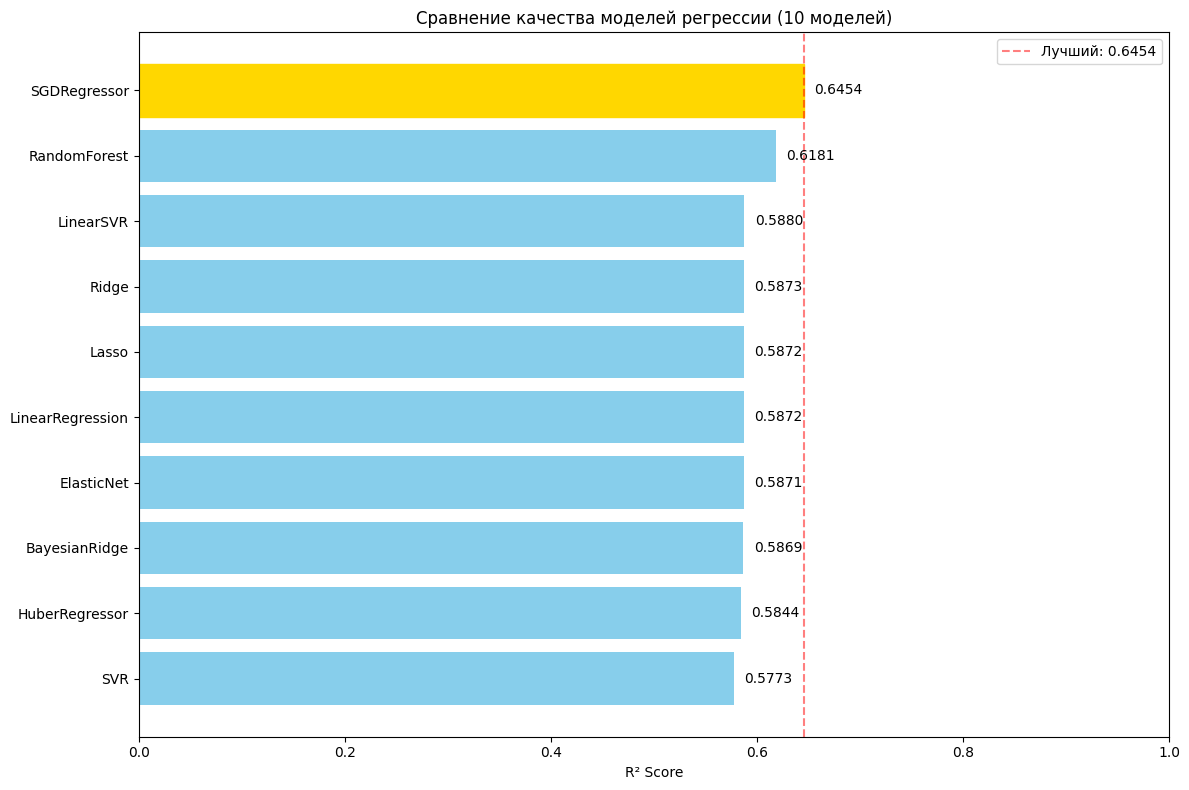

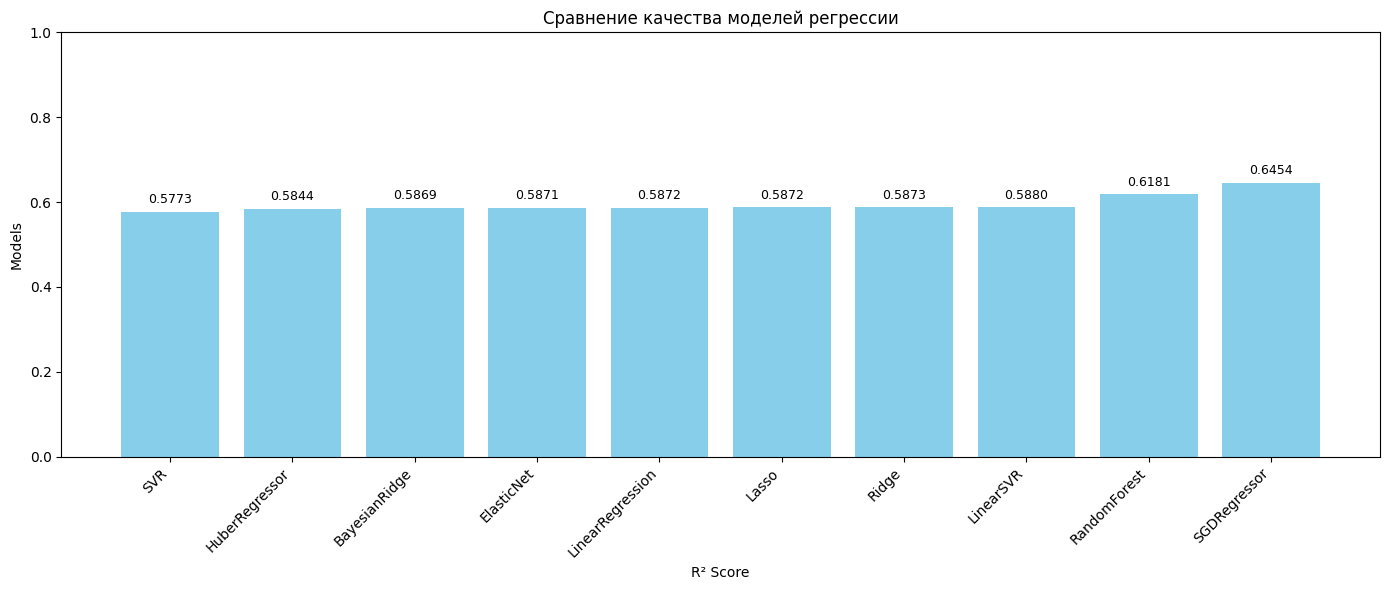

In [806]:
import matplotlib.pyplot as plt
import numpy as np

# Данные для графика (адаптируем под вашу структуру)
model_names = list(results.keys())

# Проверяем структуру results и извлекаем scores
try:
    # Если results хранит словари со score
    scores = [results[m]['score'] if isinstance(results[m], dict) else results[m] for m in model_names]
except:
    # Если results хранит просто числа
    scores = list(results.values())

print("Модели:", model_names)
print("R² scores:", [f"{s:.4f}" for s in scores])

# Сортируем для красивого графика
sorted_idx = np.argsort(scores)
model_names_sorted = [model_names[i] for i in sorted_idx]
scores_sorted = [scores[i] for i in sorted_idx]

# Создаём график
plt.figure(figsize=(12, 8))
bars = plt.barh(model_names_sorted, scores_sorted, color='skyblue')
plt.xlabel('R² Score')
plt.title('Сравнение качества моделей регрессии (10 моделей)')
plt.xlim(0, 1)  # R² обычно от 0 до 1

# Добавляем значения на бары
for bar, score in zip(bars, scores_sorted):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{score:.4f}', va='center', fontsize=10)

# Отмечаем лучшую модель
best_idx = np.argmax(scores_sorted)
bars[best_idx].set_color('gold')
plt.axvline(x=max(scores), color='red', linestyle='--', alpha=0.5, 
            label=f'Лучший: {max(scores):.4f}')
plt.legend()
plt.tight_layout()
plt.show()

# Дополнительно: горизонтальная версия
plt.figure(figsize=(14, 6))
plt.bar(model_names_sorted, scores_sorted, color='skyblue')
plt.xlabel('R² Score')
plt.ylabel('Models')
plt.title('Сравнение качества моделей регрессии')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
for i, (name, score) in enumerate(zip(model_names_sorted, scores_sorted)):
    plt.text(i, score + 0.02, f'{score:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Обучение лучшей модели и сохранение в model_resume_matcher

In [819]:

#пайплайн модели
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.pipeline import Pipeline

class MyTransformer(TransformerMixin, BaseEstimator):
    '''Шаблон кастомного трансформера'''
 
    def __init__(self):
        '''
        Здесь прописывается инициализация параметров, не зависящих от данных.
        '''
        pass
 
    def fit(self, X, y=None):
        '''
        Здесь прописывается «обучение» трансформера.
        Вычисляются необходимые для работы трансформера параметры (если они нужны).
        '''

        return self
 
    def transform(self, X):
        '''Здесь прописываются действия с данными.'''
        # Создаём новый столбец как произведение первых трёх
        new_column = X[:, 0] * X[:, 1]
        # Для добавления столбца в массив нужно изменить его размер на (n_rows, 1)
        new_column = new_column.reshape(-1, 1)
        # Добавляем столбец в матрицу измерений
        X = np.append(X, new_column, axis=1)
        return X


        return X


pipe_best = Pipeline([
    ('FeatureEngineering', MyTransformer()),
    ('scaler', StandardScaler()),
    ('SGD', SGDRegressor(
        alpha=0.01,           # из best_params
        epsilon=0.01,         #  из best_params
        eta0=0.1,             #  из best_params
        l1_ratio=0.85,        # из best_params (для elasticnet)
        learning_rate='constant',  #  из best_params
        max_iter=20000,       #  из best_params
        penalty='l2',         #  из best_params
        tol=0.001,            #  из best_params
        fit_intercept=True,
        random_state=42,
        loss='epsilon_insensitive'  # добавлено для лучшей работы
    ))
])
# Тестируем

df_pipe=pd.DataFrame(columns=['list_score_llm','list_score_cos','list_score_manual'])
df_pipe["list_score_llm"]=list_score_llm
df_pipe["list_score_cos"]=list_score_cos
df_pipe['list_score_manual']=list_score_manual
#df_pipe['llm_cos_interaction'] = df_pipe['list_score_llm'] * df_train['list_score_cos']
print(df_pipe.info())
X_pipe=df_pipe.drop(columns='list_score_manual').values
y_pipe=df_pipe['list_score_manual'].values
#print(f"После трансформации стало признаков: {pipe.named_steps['FeatureEngineering'].transform(X_train).shape[1]}")
pipe_best.fit(X_pipe,y_pipe)

# Предсказание для новых данных

y_pred = np.clip(pipe_best.predict(X_pipe), 0, 100)
print(np.round(y_pred,0))
print(len(y_pred))
print(y)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   list_score_llm     150 non-null    float64
 1   list_score_cos     150 non-null    float64
 2   list_score_manual  150 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 3.6 KB
None
[ 99.  90.  74.  69.  72.  70.  67.  67.  64.  66.  68.  55.  62.  62.
  62.  61.  57.  56.  54.  54.  49.  41.  50.  48.  45.  43.  34.  29.
  29.  19. 100.  99.  87.  81.  81.  79.  80.  70.  71.  65.  66.  63.
  59.  55.  52.  42.  46.  42.  44.  32.  37.  35.  35.  37.  22.  31.
  31.  26.  23.  17. 100.  95.  91.  75.  77.  74.  69.  62.  61.  58.
  56.  45.  42.  44.  40.  35.  41.  40.  35.  30.  29.  24.  21.  21.
  24.  20.  19.   7.  13.   9.  95.  94.  85.  74.  71.  66.  61.  56.
  54.  45.  46.  40.  38.  37.  36.  30.  29.  32.  27.  26.  24.  27.
  25.  20.  13.  21.  21.  18.  15.  11.  67

In [820]:
import pickle
# Сериализуем pipeline и записываем результат в файл
with open('model_best_resume_matcher.pkl', 'wb') as output:
    pickle.dump(pipe_best, output)

# Валидация повторения

In [821]:
# Десериализуем pipeline из файла
import joblib

# Загрузка модели
loaded_pipe = joblib.load('model_best_resume_matcher.pkl')

# Использование
y_pred = loaded_pipe.predict(X_pipe)

y_pred = np.clip(pipe_best.predict(X_pipe), 0, 100)
print(np.round(y_pred,0))


print(len(y_pred))
print(y)

[ 99.  90.  74.  69.  72.  70.  67.  67.  64.  66.  68.  55.  62.  62.
  62.  61.  57.  56.  54.  54.  49.  41.  50.  48.  45.  43.  34.  29.
  29.  19. 100.  99.  87.  81.  81.  79.  80.  70.  71.  65.  66.  63.
  59.  55.  52.  42.  46.  42.  44.  32.  37.  35.  35.  37.  22.  31.
  31.  26.  23.  17. 100.  95.  91.  75.  77.  74.  69.  62.  61.  58.
  56.  45.  42.  44.  40.  35.  41.  40.  35.  30.  29.  24.  21.  21.
  24.  20.  19.   7.  13.   9.  95.  94.  85.  74.  71.  66.  61.  56.
  54.  45.  46.  40.  38.  37.  36.  30.  29.  32.  27.  26.  24.  27.
  25.  20.  13.  21.  21.  18.  15.  11.  67.  63.  58.  62.  60.  61.
  56.  56.  54.  53.  53.  53.  52.  51.  39.  43.  38.  41.  37.  32.
  39.  33.  35.  34.  35.  31.  30.  27.  27.  11.]
150
[100 100  70  40  45  35  88  45  45  40  65  70  50  54  53  67  70  60
  45  55  40  35  35  70  73  67  39  35  33  28 100  93  80 100  90  93
  85  80  79  30  70  65  60  50  67  45  62  35  32  45  54  43  30  29
  25  40  35  4

# Вывод

В ходе тестов было выявлено, что комбинация COS_score и метрики LLM давала завышенные оценки, даже для кандидатов с низкими метриками. Особенно это проявлялось на граничных случаях, где один из признаков был высоким, а другой — низким. Простое линейное взвешивание (например, 0.4×COS + 0.6×LLM) не позволяло гибко скорректировать такие аномалии.

Для исправления этого перекоса было принято решение обучить ML-модель-калибратор на пространстве признаков [LLM_score, COS_score] с использованием ручной разметки (200+ пар "резюме-вакансия"). Дополнительно был добавлен признак взаимодействия (interaction = COS × LLM), позволивший модели учитывать нелинейные эффекты.

**Дальнейшие улучшения:**
- Накопление большего объёма размеченных данных (цель: 1000+ пар)
- Эксперименты с нелинейными моделями 
- Расширение признакового пространства
- Внедрение онлайн-дообучения по мере поступления новых экспертных оценок